# Employee Attrition Analysis
## Week 1: Business Understanding and Data Exploration

**Project objective:** Explore the IBM HR Analytics dataset to understand employee attrition patterns, identify workforce groups with elevated attrition rates, and translate findings into practical business recommendations.

**Scope:** Business understanding, data quality assessment, descriptive statistics, exploratory data analysis, and business insights. Predictive modelling is intentionally excluded from this Week 1 analysis.

**Dataset:** IBM HR Analytics – Employee Attrition & Performance  
**Unit of analysis:** One employee per row  
**Target variable:** `Attrition` (`Yes` or `No`)


## 1. Business Understanding

Employee attrition creates recruitment, onboarding, productivity, and knowledge-retention costs. The business needs evidence showing where attrition is concentrated and which employee characteristics are associated with higher turnover.

### Business problem
Determine which workforce characteristics and employment conditions are associated with employee attrition.

### Analytical questions
1. What is the overall employee attrition rate?
2. Which departments and job roles have the highest attrition rates?
3. Is attrition associated with overtime or business travel?
4. How do age, income, tenure, job satisfaction, and work-life balance differ between employees who leave and those who remain?
5. Which employee groups should HR prioritise for retention interventions?

### Success criteria
The analysis should:
- accurately describe the dataset and its quality;
- quantify attrition using counts and rates;
- identify notable employee segments;
- communicate limitations and avoid claiming causation;
- provide practical, evidence-based recommendations.


In [1]:
# Import libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Load the dataset
DATA_PATH = Path("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

if not DATA_PATH.exists():
    # Fallback for running the notebook from a different working directory
    DATA_PATH = Path("/mnt/data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 1,470
Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 2. Data Understanding and Quality Assessment

This section examines structure, data types, missing values, duplicate rows, unique values, and columns that do not vary.


In [3]:
# Dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Data quality summary
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique(dropna=False)
}).sort_values(["Missing Values", "Unique Values"], ascending=[False, True])

print(f"Duplicate rows: {df.duplicated().sum():,}")
quality_summary


Duplicate rows: 0


,Data Type,Missing Values,Missing Percentage,Unique Values
EmployeeCount,int64,0,0.00,1
Over18,object,0,0.00,1
StandardHours,int64,0,0.00,1
Attrition,object,0,0.00,2
Gender,object,0,0.00,2
OverTime,object,0,0.00,2
PerformanceRating,int64,0,0.00,2
BusinessTravel,object,0,0.00,3
Department,object,0,0.00,3
MaritalStatus,object,0,0.00,3


In [5]:
# Identify constant columns and identifier-like columns
constant_columns = [column for column in df.columns if df[column].nunique(dropna=False) == 1]
identifier_columns = ["EmployeeNumber"]

print("Constant columns:", constant_columns)
print("Identifier columns:", identifier_columns)


Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Identifier columns: ['EmployeeNumber']


### Data-quality decisions

- No missing values are present.
- No duplicate rows are present.
- `EmployeeCount`, `Over18`, and `StandardHours` are constant and cannot explain variation in attrition.
- `EmployeeNumber` is an identifier rather than an employee characteristic.
- These columns are removed from the analytical copy, while the original dataframe remains unchanged.


In [6]:
# Prepare the analytical dataframe
columns_to_drop = constant_columns + identifier_columns
analysis_df = df.drop(columns=columns_to_drop).copy()
analysis_df["AttritionFlag"] = (analysis_df["Attrition"] == "Yes").astype(int)

print(f"Analytical rows: {analysis_df.shape[0]:,}")
print(f"Analytical columns: {analysis_df.shape[1]}")


Analytical rows: 1,470
Analytical columns: 32


## 3. Descriptive Statistics


In [7]:
# Numerical descriptive statistics
analysis_df.select_dtypes(include=np.number).describe().T


,count,mean,std,min,25%,50%,75%,max
Age,"1,470.00",36.92,9.14,18.00,30.00,36.00,43.00,60.00
DailyRate,"1,470.00",802.49,403.51,102.00,465.00,802.00,"1,157.00","1,499.00"
DistanceFromHome,"1,470.00",9.19,8.11,1.00,2.00,7.00,14.00,29.00
Education,"1,470.00",2.91,1.02,1.00,2.00,3.00,4.00,5.00
EnvironmentSatisfaction,"1,470.00",2.72,1.09,1.00,2.00,3.00,4.00,4.00
HourlyRate,"1,470.00",65.89,20.33,30.00,48.00,66.00,83.75,100.00
JobInvolvement,"1,470.00",2.73,0.71,1.00,2.00,3.00,3.00,4.00
JobLevel,"1,470.00",2.06,1.11,1.00,1.00,2.00,3.00,5.00
JobSatisfaction,"1,470.00",2.73,1.10,1.00,2.00,3.00,4.00,4.00
MonthlyIncome,"1,470.00","6,502.93","4,707.96","1,009.00","2,911.00","4,919.00","8,379.00","19,999.00"


In [8]:
# Categorical variable summary
categorical_summary = pd.DataFrame({
    "Unique Categories": analysis_df.select_dtypes(exclude=np.number).nunique(),
    "Most Common Value": analysis_df.select_dtypes(exclude=np.number).mode().iloc[0],
    "Most Common Count": [
        analysis_df[column].value_counts().iloc[0]
        for column in analysis_df.select_dtypes(exclude=np.number).columns
    ]
})
categorical_summary


,Unique Categories,Most Common Value,Most Common Count
Attrition,2,No,1233
BusinessTravel,3,Travel_Rarely,1043
Department,3,Research & Development,961
EducationField,6,Life Sciences,606
Gender,2,Male,882
JobRole,9,Sales Executive,326
MaritalStatus,3,Married,673
OverTime,2,No,1054


## 4. Overall Attrition


In [9]:
# Attrition count and rate
attrition_summary = (
    analysis_df["Attrition"]
    .value_counts()
    .rename_axis("Attrition")
    .reset_index(name="Employees")
)
attrition_summary["Percentage"] = (
    attrition_summary["Employees"] / len(analysis_df) * 100
).round(2)

attrition_summary


,Attrition,Employees,Percentage
0,No,1233,83.88
1,Yes,237,16.12


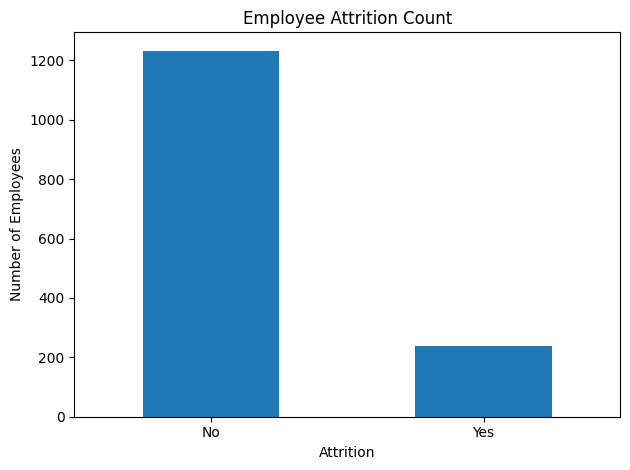

In [10]:
# Plot overall attrition
attrition_summary.set_index("Attrition")["Employees"].plot(
    kind="bar",
    title="Employee Attrition Count",
    xlabel="Attrition",
    ylabel="Number of Employees",
    rot=0
)
plt.tight_layout()
plt.show()


**Interpretation:** Attrition is an imbalanced outcome. Most employees remain in the organisation, so attrition rates—not only raw counts—should be used when comparing workforce groups.


## 5. Attrition by Categorical Employee Characteristics

The helper function below reports employee count, attrition count, and attrition rate for each category.


In [11]:
def attrition_by_category(data, column, minimum_group_size=1):
    """Calculate attrition counts and rates for categories in a column."""
    result = (
        data.groupby(column, dropna=False)
        .agg(
            Employees=("AttritionFlag", "size"),
            Attrition_Count=("AttritionFlag", "sum"),
            Attrition_Rate=("AttritionFlag", "mean")
        )
        .reset_index()
    )
    result["Attrition_Rate"] = (result["Attrition_Rate"] * 100).round(2)
    return (
        result[result["Employees"] >= minimum_group_size]
        .sort_values("Attrition_Rate", ascending=False)
        .reset_index(drop=True)
    )


In [12]:
# Overtime
overtime_summary = attrition_by_category(analysis_df, "OverTime")
overtime_summary


,OverTime,Employees,Attrition_Count,Attrition_Rate
0,Yes,416,127,30.53
1,No,1054,110,10.44


In [13]:
# Business travel
travel_summary = attrition_by_category(analysis_df, "BusinessTravel")
travel_summary


,BusinessTravel,Employees,Attrition_Count,Attrition_Rate
0,Travel_Frequently,277,69,24.91
1,Travel_Rarely,1043,156,14.96
2,Non-Travel,150,12,8.00


In [14]:
# Department
department_summary = attrition_by_category(analysis_df, "Department")
department_summary


,Department,Employees,Attrition_Count,Attrition_Rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


In [15]:
# Job role
job_role_summary = attrition_by_category(analysis_df, "JobRole")
job_role_summary


,JobRole,Employees,Attrition_Count,Attrition_Rate
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


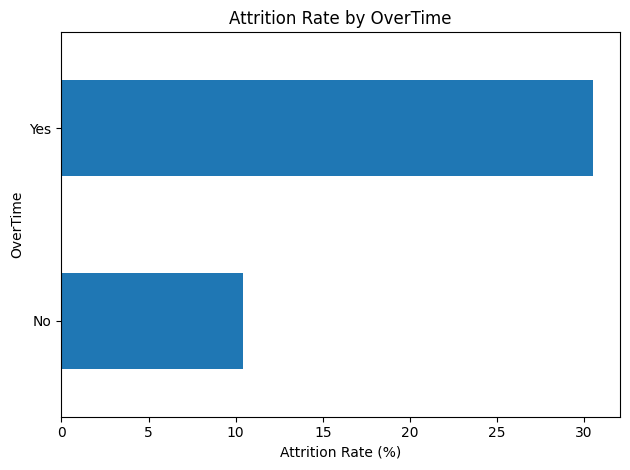

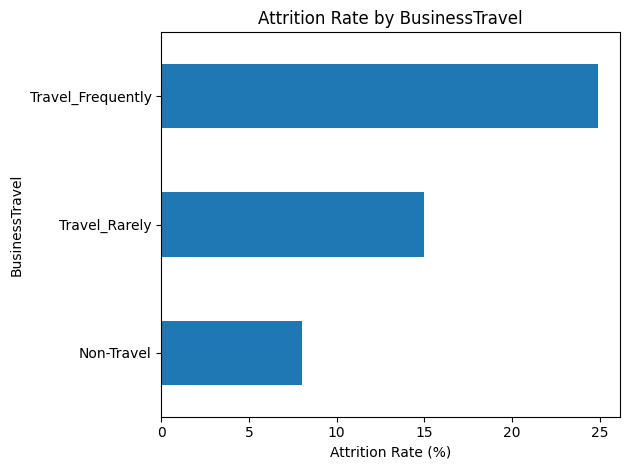

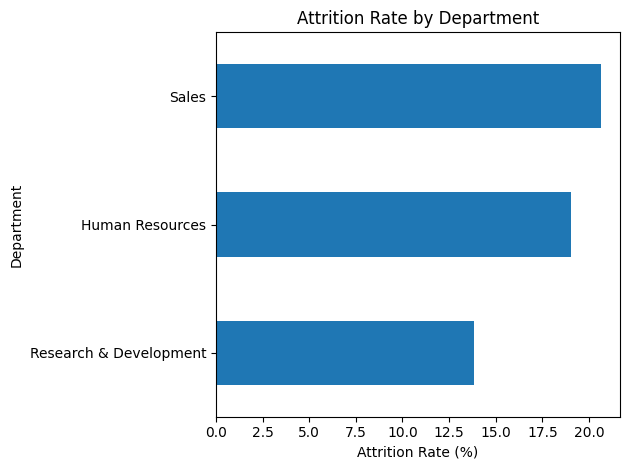

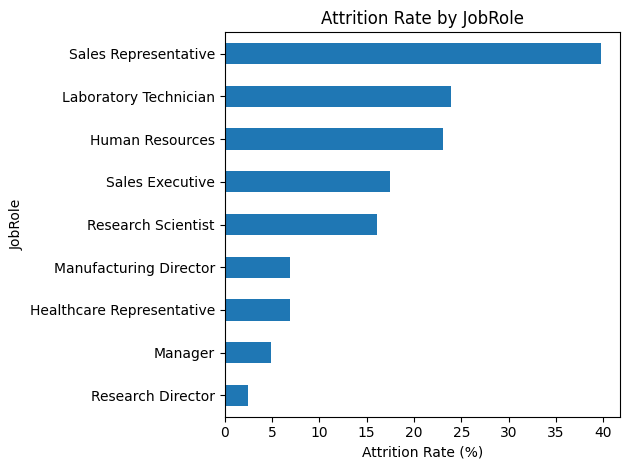

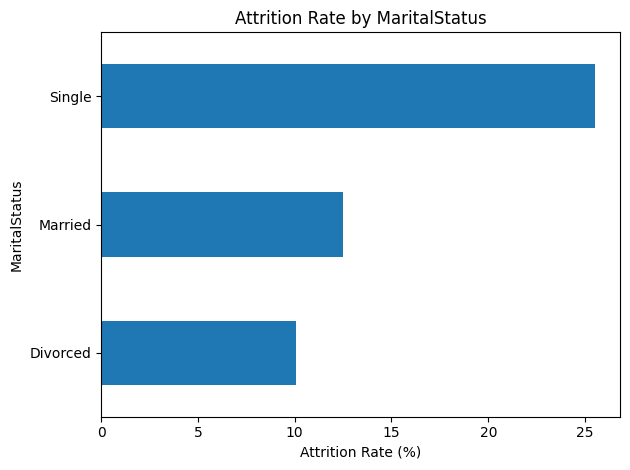

In [16]:
# Plot selected categorical attrition rates
for column in ["OverTime", "BusinessTravel", "Department", "JobRole", "MaritalStatus"]:
    table = attrition_by_category(analysis_df, column)
    table.sort_values("Attrition_Rate").set_index(column)["Attrition_Rate"].plot(
        kind="barh",
        title=f"Attrition Rate by {column}",
        xlabel="Attrition Rate (%)",
        ylabel=column
    )
    plt.tight_layout()
    plt.show()


## 6. Attrition by Satisfaction and Work Conditions


In [17]:
# Satisfaction and employment-condition variables
condition_columns = [
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "StockOptionLevel",
    "JobLevel"
]

condition_tables = {}
for column in condition_columns:
    condition_tables[column] = attrition_by_category(analysis_df, column)
    print(f"\n{column}")
    display(condition_tables[column])



EnvironmentSatisfaction


,EnvironmentSatisfaction,Employees,Attrition_Count,Attrition_Rate
0,1,284,72,25.35
1,2,287,43,14.98
2,3,453,62,13.69
3,4,446,60,13.45



JobInvolvement


,JobInvolvement,Employees,Attrition_Count,Attrition_Rate
0,1,83,28,33.73
1,2,375,71,18.93
2,3,868,125,14.40
3,4,144,13,9.03



JobSatisfaction


...

,WorkLifeBalance,Employees,Attrition_Count,Attrition_Rate
0,1,80,25,31.25
1,4,153,27,17.65
2,2,344,58,16.86
3,3,893,127,14.22



StockOptionLevel


,StockOptionLevel,Employees,Attrition_Count,Attrition_Rate
0,0,631,154,24.41
1,3,85,15,17.65
2,1,596,56,9.40
3,2,158,12,7.59



JobLevel


,JobLevel,Employees,Attrition_Count,Attrition_Rate
0,1,543,143,26.34
1,3,218,32,14.68
2,2,534,52,9.74
3,5,69,5,7.25
4,4,106,5,4.72


## 7. Numerical Comparisons


In [18]:
# Compare selected numerical averages by attrition status
selected_numeric_columns = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "NumCompaniesWorked"
]

numeric_comparison = (
    analysis_df.groupby("Attrition")[selected_numeric_columns]
    .mean()
    .T
)
numeric_comparison["Difference: Yes - No"] = (
    numeric_comparison["Yes"] - numeric_comparison["No"]
)
numeric_comparison.round(2)


Attrition,No,Yes,Difference: Yes - No
Age,37.56,33.61,-3.95
MonthlyIncome,"6,832.74","4,787.09","-2,045.65"
DistanceFromHome,8.92,10.63,1.72
TotalWorkingYears,11.86,8.24,-3.62
YearsAtCompany,7.37,5.13,-2.24
YearsInCurrentRole,4.48,2.90,-1.58
YearsSinceLastPromotion,2.23,1.95,-0.29
YearsWithCurrManager,4.37,2.85,-1.52
NumCompaniesWorked,2.65,2.94,0.30


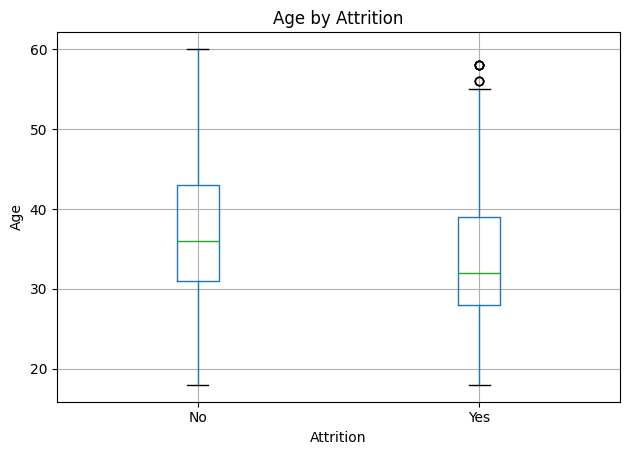

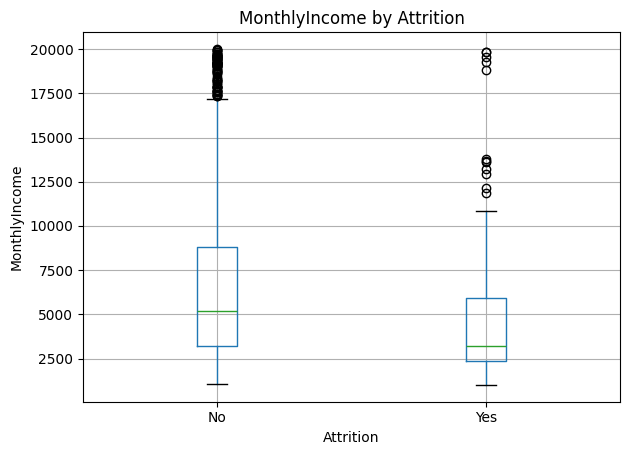

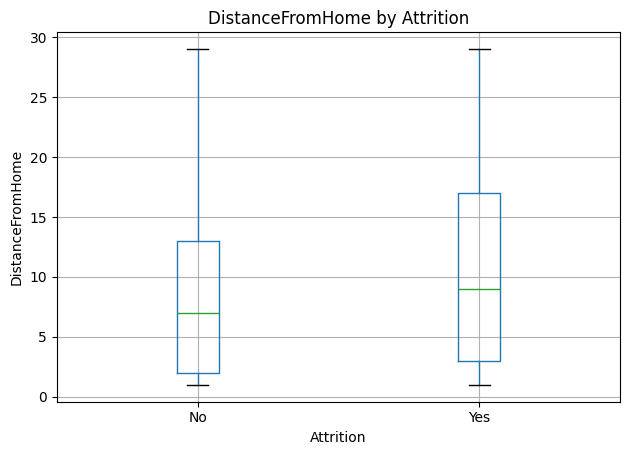

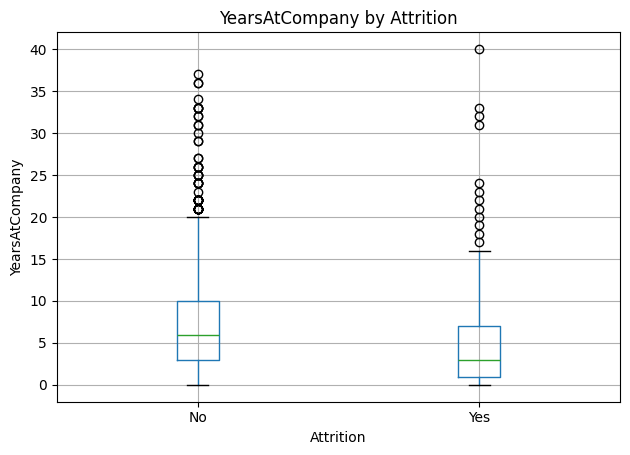

In [19]:
# Box plots for selected numerical variables
for column in ["Age", "MonthlyIncome", "DistanceFromHome", "YearsAtCompany"]:
    analysis_df.boxplot(column=column, by="Attrition")
    plt.title(f"{column} by Attrition")
    plt.suptitle("")
    plt.xlabel("Attrition")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()


## 7A. Statistical Significance Testing

Descriptive differences do not necessarily mean that a relationship is statistically meaningful. This section tests whether selected categorical and numerical variables are significantly associated with employee attrition.

- **Chi-square tests of independence** are used for categorical variables.
- **Welch’s independent t-tests** are used for numerical variables because they do not assume equal group variances.
- A significance level of **α = 0.05** is used.

A p-value below 0.05 indicates statistical evidence of an association or group difference in this dataset. Statistical significance does **not** establish causation.

In [20]:
# Chi-square tests for selected categorical variables
categorical_test_columns = [
    "OverTime",
    "BusinessTravel",
    "Department",
    "JobRole",
    "MaritalStatus",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement"
]

chi_square_results = []

for column in categorical_test_columns:
    contingency_table = pd.crosstab(analysis_df[column], analysis_df["Attrition"])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    chi_square_results.append({
        "Variable": column,
        "Chi-square": round(chi2, 3),
        "Degrees of Freedom": dof,
        "p-value": p_value,
        "Significant (p < 0.05)": p_value < 0.05
    })

chi_square_results = (
    pd.DataFrame(chi_square_results)
    .sort_values("p-value")
    .reset_index(drop=True)
)

chi_square_results

,Variable,Chi-square,Degrees of Freedom,p-value,Significant (p < 0.05)
0,OverTime,87.56,1,0.00,True
1,JobRole,86.19,8,0.00,True
2,MaritalStatus,46.16,2,0.00,True
3,JobInvolvement,28.49,3,0.00,True
4,BusinessTravel,24.18,2,0.00,True
5,EnvironmentSatisfaction,22.50,3,0.00,True
6,JobSatisfaction,17.50,3,0.00,True
7,WorkLifeBalance,16.32,3,0.00,True
8,Department,10.80,2,0.00,True


In [21]:
# Welch's independent t-tests for selected numerical variables
left_group = analysis_df[analysis_df["Attrition"] == "Yes"]
stay_group = analysis_df[analysis_df["Attrition"] == "No"]

numerical_test_columns = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

t_test_results = []

for column in numerical_test_columns:
    t_statistic, p_value = stats.ttest_ind(
        left_group[column],
        stay_group[column],
        equal_var=False,
        nan_policy="omit"
    )

    t_test_results.append({
        "Variable": column,
        "Mean - Left": round(left_group[column].mean(), 2),
        "Mean - Stayed": round(stay_group[column].mean(), 2),
        "Mean Difference": round(
            left_group[column].mean() - stay_group[column].mean(), 2
        ),
        "t-statistic": round(t_statistic, 3),
        "p-value": p_value,
        "Significant (p < 0.05)": p_value < 0.05
    })

t_test_results = (
    pd.DataFrame(t_test_results)
    .sort_values("p-value")
    .reset_index(drop=True)
)

t_test_results

,Variable,Mean - Left,Mean - Stayed,Mean Difference,t-statistic,p-value,Significant (p < 0.05)
0,MonthlyIncome,"4,787.09","6,832.74","-2,045.65",-7.48,0.00,True
1,TotalWorkingYears,8.24,11.86,-3.62,-7.02,0.00,True
2,YearsInCurrentRole,2.90,4.48,-1.58,-6.85,0.00,True
3,YearsWithCurrManager,2.85,4.37,-1.52,-6.63,0.00,True
4,Age,33.61,37.56,-3.95,-5.83,0.00,True
5,YearsAtCompany,5.13,7.37,-2.24,-5.28,0.00,True
6,DistanceFromHome,10.63,8.92,1.72,2.89,0.00,True
7,YearsSinceLastPromotion,1.95,2.23,-0.29,-1.29,0.20,False


### Statistical interpretation

Use the **p-value** together with the descriptive results. A statistically significant result indicates that the observed association or difference is unlikely to be explained by random sampling variation alone under the null hypothesis. It does not show that the variable causes attrition.

## 7B. Interaction Analysis

Single-variable comparisons can hide important patterns. The following analyses examine whether attrition is concentrated in particular combinations of employee characteristics.

### Overtime × Job Role

This analysis compares attrition rates across combinations of job role and overtime status. Groups with very small employee counts should be interpreted cautiously.

In [22]:
# Interaction: Overtime by Job Role
overtime_jobrole = (
    analysis_df.groupby(["JobRole", "OverTime"], observed=False)
    .agg(
        Employees=("AttritionFlag", "size"),
        Attrition_Count=("AttritionFlag", "sum"),
        Attrition_Rate=("AttritionFlag", "mean")
    )
    .reset_index()
)

overtime_jobrole["Attrition_Rate"] = (
    overtime_jobrole["Attrition_Rate"] * 100
).round(2)

# Focus interpretation on groups with at least 10 employees
overtime_jobrole_filtered = (
    overtime_jobrole[overtime_jobrole["Employees"] >= 10]
    .sort_values("Attrition_Rate", ascending=False)
    .reset_index(drop=True)
)

overtime_jobrole_filtered

,JobRole,OverTime,Employees,Attrition_Count,Attrition_Rate
0,Sales Representative,Yes,24,16,66.67
1,Laboratory Technician,Yes,62,31,50.00
2,Human Resources,Yes,13,5,38.46
3,Research Scientist,Yes,97,33,34.02
4,Sales Executive,Yes,94,31,32.98
5,Sales Representative,No,59,17,28.81
6,Human Resources,No,39,7,17.95
7,Laboratory Technician,No,197,31,15.74
8,Manager,Yes,27,4,14.81
9,Sales Executive,No,232,26,11.21


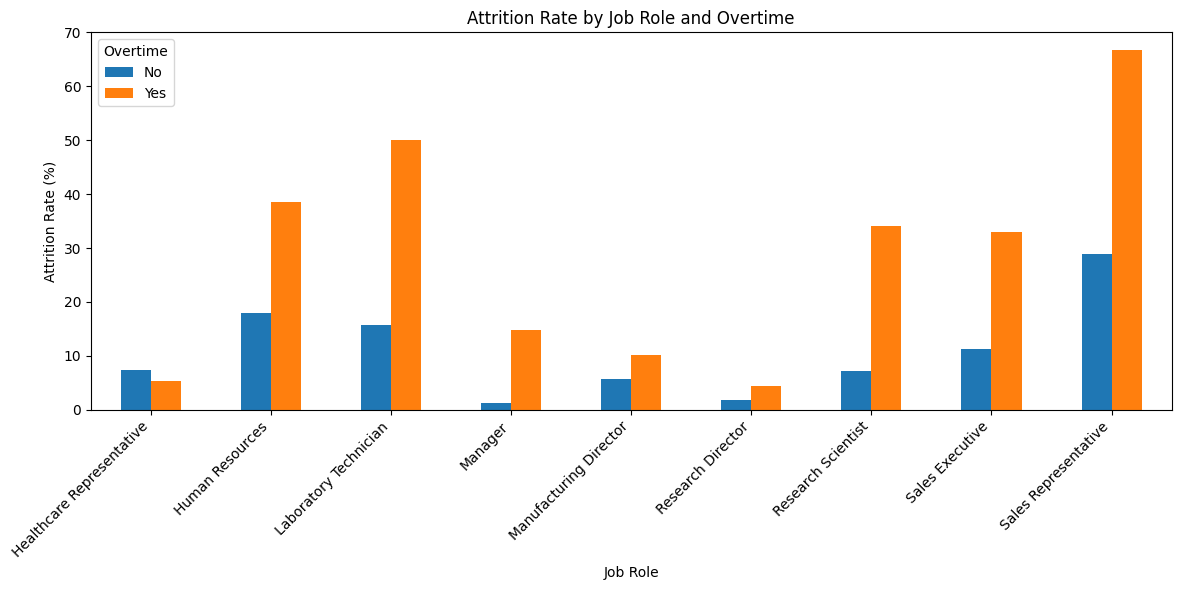

In [23]:
# Visualise attrition rate by Job Role and Overtime
overtime_plot = overtime_jobrole.pivot(
    index="JobRole",
    columns="OverTime",
    values="Attrition_Rate"
)

overtime_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Attrition Rate by Job Role and Overtime")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Overtime")
plt.tight_layout()
plt.show()

### Business Travel × Department

This analysis checks whether the relationship between business travel and attrition differs across departments.

In [24]:
# Interaction: Business Travel by Department
travel_department = (
    analysis_df.groupby(["Department", "BusinessTravel"], observed=False)
    .agg(
        Employees=("AttritionFlag", "size"),
        Attrition_Count=("AttritionFlag", "sum"),
        Attrition_Rate=("AttritionFlag", "mean")
    )
    .reset_index()
)

travel_department["Attrition_Rate"] = (
    travel_department["Attrition_Rate"] * 100
).round(2)

travel_department.sort_values(
    "Attrition_Rate", ascending=False
).reset_index(drop=True)

,Department,BusinessTravel,Employees,Attrition_Count,Attrition_Rate
0,Human Resources,Travel_Frequently,11,4,36.36
1,Sales,Travel_Frequently,84,28,33.33
2,Research & Development,Travel_Frequently,182,37,20.33
3,Sales,Travel_Rarely,315,60,19.05
4,Human Resources,Travel_Rarely,46,8,17.39
5,Research & Development,Travel_Rarely,682,88,12.90
6,Sales,Non-Travel,47,4,8.51
7,Research & Development,Non-Travel,97,8,8.25
8,Human Resources,Non-Travel,6,0,0.00


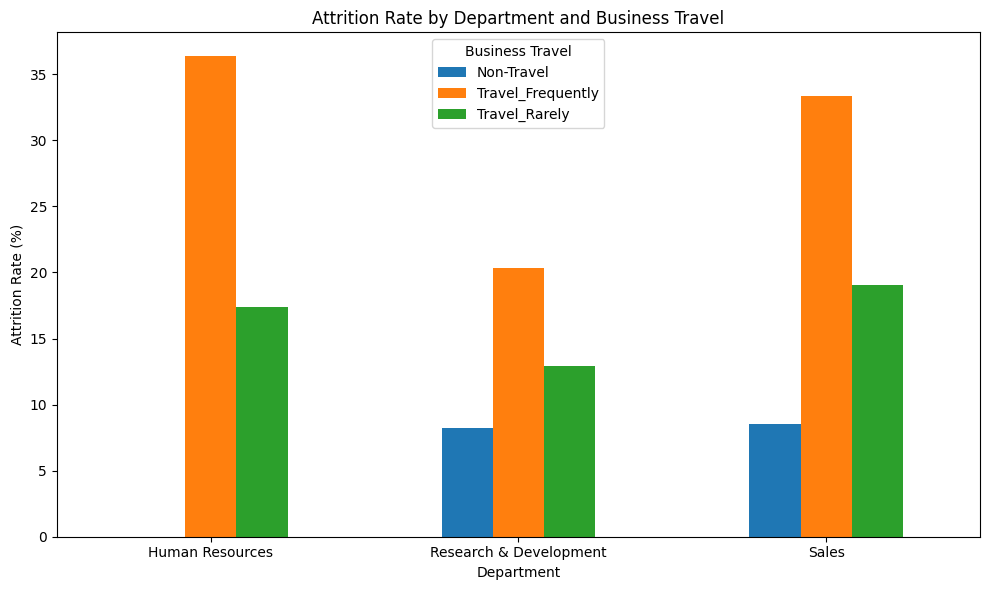

In [25]:
# Visualise attrition rate by Department and Business Travel
travel_plot = travel_department.pivot(
    index="Department",
    columns="BusinessTravel",
    values="Attrition_Rate"
)

travel_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Attrition Rate by Department and Business Travel")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Business Travel")
plt.tight_layout()
plt.show()

### Interaction-analysis interpretation

These interaction tables help identify **where** elevated attrition is concentrated rather than treating overtime or travel as uniform across the organisation. The employee count should always be considered alongside the attrition rate, because very small groups can produce unstable percentages.

## 8. Employee Segmentation

Age and company-tenure bands make numerical patterns easier to communicate to business stakeholders.


In [26]:
# Create age and tenure bands
analysis_df["AgeBand"] = pd.cut(
    analysis_df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18–25", "26–35", "36–45", "46–55", "56–65"]
)

analysis_df["TenureBand"] = pd.cut(
    analysis_df["YearsAtCompany"],
    bins=[-1, 1, 3, 5, 10, np.inf],
    labels=["0–1 years", "2–3 years", "4–5 years", "6–10 years", "11+ years"]
)

print("Attrition by age band")
display(attrition_by_category(analysis_df, "AgeBand"))

print("Attrition by tenure band")
display(attrition_by_category(analysis_df, "TenureBand"))


Attrition by age band


/tmp/ipykernel_1297/58734643.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column, dropna=False)


,AgeBand,Employees,Attrition_Count,Attrition_Rate
0,18–25,123,44,35.77
1,26–35,606,116,19.14
2,56–65,47,8,17.02
3,46–55,226,26,11.50
4,36–45,468,43,9.19


Attrition by tenure band


/tmp/ipykernel_1297/58734643.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column, dropna=False)


,TenureBand,Employees,Attrition_Count,Attrition_Rate
0,0–1 years,215,75,34.88
1,2–3 years,255,47,18.43
2,4–5 years,306,40,13.07
3,6–10 years,448,55,12.28
4,11+ years,246,20,8.13


/tmp/ipykernel_1297/58734643.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column, dropna=False)


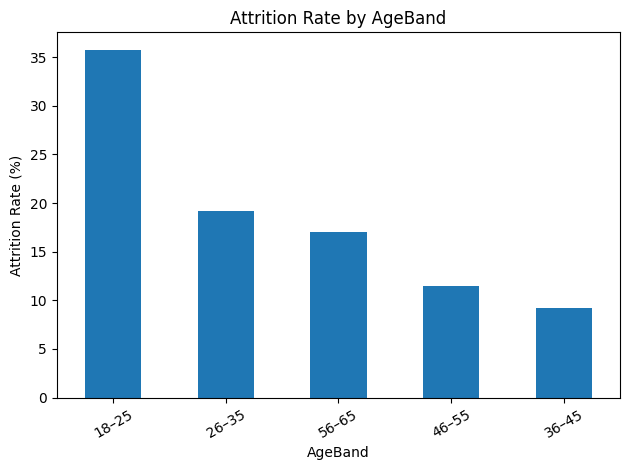

/tmp/ipykernel_1297/58734643.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column, dropna=False)


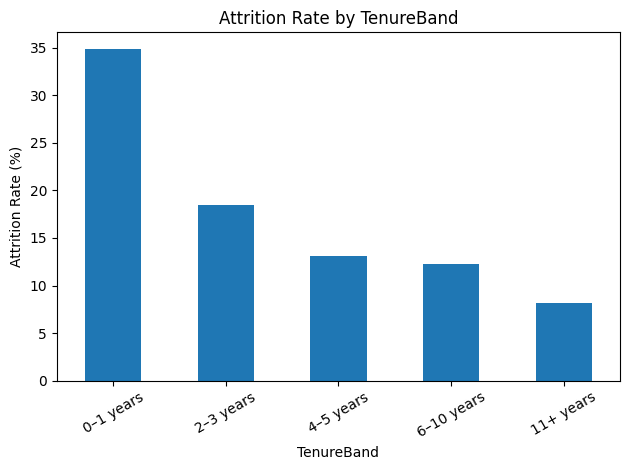

In [27]:
# Visualise segmented attrition rates
for column in ["AgeBand", "TenureBand"]:
    table = attrition_by_category(analysis_df, column)
    table.set_index(column)["Attrition_Rate"].plot(
        kind="bar",
        title=f"Attrition Rate by {column}",
        xlabel=column,
        ylabel="Attrition Rate (%)",
        rot=30
    )
    plt.tight_layout()
    plt.show()


## 9. Correlation Exploration

Correlation describes linear association between numerical variables. It does not establish causation. The binary `AttritionFlag` is included only as an exploratory indicator.


In [28]:
# Correlations with the attrition flag
numeric_correlations = (
    analysis_df.select_dtypes(include=np.number)
    .corr()["AttritionFlag"]
    .drop("AttritionFlag")
    .sort_values()
)

print("Most negative correlations")
display(numeric_correlations.head(10).to_frame("Correlation"))

print("Most positive correlations")
display(numeric_correlations.tail(10).sort_values(ascending=False).to_frame("Correlation"))


Most negative correlations


,Correlation
TotalWorkingYears,-0.17
JobLevel,-0.17
YearsInCurrentRole,-0.16
MonthlyIncome,-0.16
Age,-0.16
YearsWithCurrManager,-0.16
StockOptionLevel,-0.14
YearsAtCompany,-0.13
JobInvolvement,-0.13
JobSatisfaction,-0.10


Most positive correlations


,Correlation
DistanceFromHome,0.08
NumCompaniesWorked,0.04
MonthlyRate,0.02
PerformanceRating,0.00
HourlyRate,-0.01
PercentSalaryHike,-0.01
Education,-0.03
YearsSinceLastPromotion,-0.03
RelationshipSatisfaction,-0.05
DailyRate,-0.06


## 10. Key Findings

Based on this dataset:

1. **Overall attrition is 16.12%.** There are 237 employees marked as having left and 1,233 who remained.
2. **Overtime is the clearest categorical difference.** Employees working overtime have an attrition rate of approximately 30.53%, compared with 10.44% among employees who do not work overtime.
3. **Frequent travel is associated with higher attrition.** Employees who travel frequently have an attrition rate of approximately 24.91%, compared with 14.96% for rare travel and 8.00% for non-travel.
4. **Several job roles have elevated attrition rates.** Sales Representatives have the highest observed role-level rate, followed by Laboratory Technicians and Human Resources employees. Group sizes should be considered when interpreting these rates.
5. **Employees who left are younger on average.** Their mean age is approximately 33.61 years, compared with 37.56 years among employees who stayed.
6. **Employees who left have lower average monthly income.** Their mean monthly income is approximately 4,787, compared with 6,833 for employees who stayed. This is an association and may partly reflect job level, role, or experience.
7. **Employees who left have shorter tenure.** They have fewer total working years, fewer years at the company, fewer years in their current role, and fewer years with their current manager on average.
8. **Distance from home is somewhat higher among employees who left.** The mean is approximately 10.63 compared with 8.92 among employees who stayed.

These findings identify associations within the supplied dataset; they do not prove that any single characteristic causes attrition.


## 11. Business Recommendations

1. **Review overtime practices.** HR and department leaders should identify teams with sustained overtime, examine workload allocation, and track whether overtime is voluntary, seasonal, or chronic.
2. **Support frequent travellers.** Consider travel rotation, recovery time, flexible work arrangements, and regular wellbeing check-ins for employees with heavy travel schedules.
3. **Prioritise high-risk roles.** Conduct role-specific retention reviews for Sales Representatives, Laboratory Technicians, and other roles with elevated rates, while considering the number of employees in each group.
4. **Strengthen early-career retention.** Improve onboarding, mentoring, development plans, and manager check-ins for younger and shorter-tenure employees.
5. **Review reward and progression structures.** Examine whether compensation, stock options, job level, development opportunities, and promotion pathways are competitive and transparent.
6. **Collect richer exit information.** Add exit-interview reasons, manager changes, workload history, engagement survey trends, and voluntary/involuntary departure status to support stronger conclusions.
7. **Measure interventions.** Track attrition rates before and after retention actions by department, role, overtime status, and tenure segment.


## 12. Limitations and Ethical Considerations

- The dataset is a static sample and may not represent the current workforce of a specific organisation.
- The analysis is observational and cannot establish cause and effect.
- The dataset does not clearly distinguish voluntary from involuntary attrition.
- Some variables are coded scales whose business meaning requires a data dictionary.
- Group-level rates can be unstable when categories contain few employees.
- Sensitive attributes such as gender and marital status should not be used to discriminate against employees.
- Any future predictive model should support fair, transparent HR decisions rather than automate adverse employment actions.


## 13. Conclusion

Employee attrition in this dataset is concentrated in identifiable workforce segments, particularly employees working overtime, travelling frequently, occupying certain job roles, earning lower average income, and having shorter work or company tenure. The strongest immediate business response is not automatic prediction but targeted investigation: review workload, travel demands, early-career support, role-specific conditions, compensation, and progression opportunities. Future analysis should test these patterns using richer organisational data and evaluate whether retention interventions reduce attrition over time.
